# Batch Pulse Response Analysis Across Sessions

This notebook automates the analysis of pulse response data across multiple sessions. It loads all relevant `.pkl` files, applies the same cluster selection and responsivity analysis pipeline as your single-session notebook, and enables comparison of trends across sessions.

## 1. Import Required Libraries
Import libraries for file handling, data analysis, and visualization.

In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100


## 2. Utility Function to Load Analysis Results
Define a function to load pulse analysis results from a .pkl file based on session ID.

In [2]:
def load_analysis_results_from_file(pkl_path):
    """
    Load pulse analysis results from a pickle file.
    Args:
        pkl_path (str): Path to the pickle file.
    Returns:
        dict: Dictionary containing analysis results.
    """
    with open(pkl_path, 'rb') as f:
        results = pickle.load(f)
    return results


## 3. Find All Session Files and Extract Session IDs
Find all relevant `.pkl` files in the `pkls/` directory and extract session IDs and dates for ordering.

In [55]:
results_dir

'../pkls'

In [48]:
# Directory containing .pkl files
results_dir = '../pkls'  # Adjust if needed
pkl_files = sorted(glob.glob(os.path.join(results_dir, 'fast_slow_results_*.pkl')))

# Extract session IDs and dates
sessions = []
for pkl_path in pkl_files:
    fname = os.path.basename(pkl_path)
    session_id = fname.replace('fast_slow_results_', '').replace('.pkl', '')
    # For your filenames, the date is always the last 8 digits of the session_id
    date_str = session_id[-8:] if session_id[-8:].isdigit() else None
    session_date = datetime.strptime(date_str, '%d%m%Y') if date_str else None
    sessions.append({'session_id': session_id, 'pkl_path': pkl_path, 'date': session_date})

# Sort sessions by date
sessions = sorted(sessions, key=lambda x: x['date'] if x['date'] else datetime.min)
print(f"Found {len(sessions)} session files.")


Found 12 session files.


## 4. Define Analysis Pipeline Functions
Define functions for cluster selection, filtering, responsivity analysis, and summary calculation (reused for each session).

In [42]:
def select_clusters(z_fast, t_vec, threshold=4.0, window=[0, 0.5]):
    window_mask = (t_vec >= window[0]) & (t_vec < window[1])
    return [clu for clu, z in z_fast.items() if np.max(z[window_mask]) > threshold]

def filter_pre_pulse(z_fast, clusters, t_vec, pre_window=[-0.05, 0], pre_activity_threshold=3):
    pre_mask = (t_vec >= pre_window[0]) & (t_vec < pre_window[1])
    filtered = []
    for clu in clusters:
        pre_max = np.max(np.abs(z_fast[clu][pre_mask]))
        if pre_max < pre_activity_threshold:
            filtered.append(clu)
    return filtered

def calculate_z_difference(z_fast, z_slow):
    return {clu: np.abs(z_fast[clu] - z_slow[clu]) for clu in z_fast.keys()}

def filter_post_pulse(z_diff, clusters, t_vec, post_window=[0, 0.5], responsivity_threshold=4):
    post_mask = (t_vec >= post_window[0]) & (t_vec < post_window[1])
    final = []
    for clu in clusters:
        max_resp = np.max(z_diff[clu][post_mask])
        if max_resp > responsivity_threshold:
            final.append(clu)
    return final

def calculate_mean_sem(z_diff, clusters):
    if not clusters:
        return None, None
    arr = np.stack([z_diff[clu] for clu in clusters])
    mean_diff = np.mean(arr, axis=0)
    sem_diff = np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])
    return mean_diff, sem_diff


## 5. Batch Process All Sessions and Collect Summary Results
Run the analysis pipeline for each session and collect summary results for cross-session comparison.

In [51]:
summary_results = []

for sess in sessions:
    results = load_analysis_results_from_file(sess['pkl_path'])
    z_fast = results['z_fast']
    z_slow = results['z_slow']
    t_vec = results['t_vec']
    z_sem_fast = results['z_sem_fast']
    z_sem_slow = results['z_sem_slow']
    # Cluster selection and filtering
    selected = select_clusters(z_fast, t_vec)
    selected = filter_pre_pulse(z_fast, selected, t_vec)
    z_diff = calculate_z_difference(z_fast, z_slow)
    selected = filter_post_pulse(z_diff, selected, t_vec)
    # Remove cluster 295 if present
    if 295 in selected:
        selected.remove(295)
    mean_diff, sem_diff = calculate_mean_sem(z_diff, selected)
    # Calculate and save mean/SEM for fast and slow traces for selected clusters
    def mean_sem_for_type(z_type, clusters):
        if not clusters:
            return None, None
        arr = np.stack([z_type[clu] for clu in clusters])
        mean = np.mean(arr, axis=0)
        sem = np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])
        return mean, sem
    mean_fast, sem_fast = mean_sem_for_type(z_fast, selected)
    mean_slow, sem_slow = mean_sem_for_type(z_slow, selected)
    # Save per-session summary as .pkl
    summary = {
        'session_id': sess['session_id'],
        'date': sess['date'],
        'n_clusters': len(selected),
        'mean_diff': mean_diff,
        'sem_diff': sem_diff,
        't_vec': t_vec,
        'selected_clusters': selected
    }
    summary_results.append(summary)
    # Optionally save per-session summary
    out_path = os.path.join(results_dir, f'summary_{sess["session_id"]}.pkl')
    with open(out_path, 'wb') as f:
        pickle.dump(summary, f)
    # Save fast and slow mean/sem for selected clusters
    fast_out = {
        'session_id': sess['session_id'],
        'date': sess['date'],
        'mean_fast': mean_fast,
        'sem_fast': sem_fast,
        't_vec': t_vec,
        'selected_clusters': selected
    }
    slow_out = {
        'session_id': sess['session_id'],
        'date': sess['date'],
        'mean_slow': mean_slow,
        'sem_slow': sem_slow,
        't_vec': t_vec,
        'selected_clusters': selected
    }
    fast_path = os.path.join(results_dir, f'fast_{sess["session_id"]}.pkl')
    slow_path = os.path.join(results_dir, f'slow_{sess["session_id"]}.pkl')
    with open(fast_path, 'wb') as f:
        pickle.dump(fast_out, f)
    with open(slow_path, 'wb') as f:
        pickle.dump(slow_out, f)
    print(f"Processed {sess['session_id']}: {len(selected)} clusters (fast/slow saved)")

Processed BG_031_28012025: 5 clusters (fast/slow saved)
Processed BG_031_18022025: 2 clusters (fast/slow saved)
Processed BG_031_25022025: 4 clusters (fast/slow saved)
Processed BG_031_27022025: 3 clusters (fast/slow saved)
Processed BG_031_11032025: 19 clusters (fast/slow saved)
Processed BG_031_14032025: 10 clusters (fast/slow saved)
Processed BG_031_26032025: 14 clusters (fast/slow saved)
Processed BG_031_02042025: 25 clusters (fast/slow saved)
Processed BG_031_25042025: 11 clusters (fast/slow saved)
Processed BG_031_01052025: 10 clusters (fast/slow saved)
Processed BG_031_08052025: 15 clusters (fast/slow saved)
Processed BG_031_21052025: 14 clusters (fast/slow saved)


## 6. Plot Trends Across Sessions
Visualize trends such as the number of responsive clusters and mean responsivity across sessions, ordered by date.

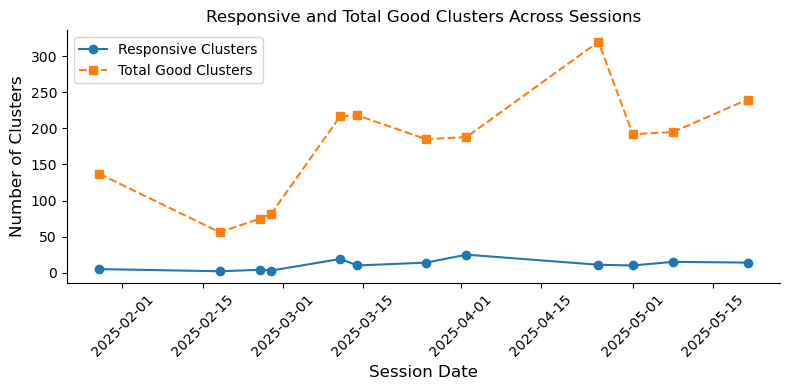

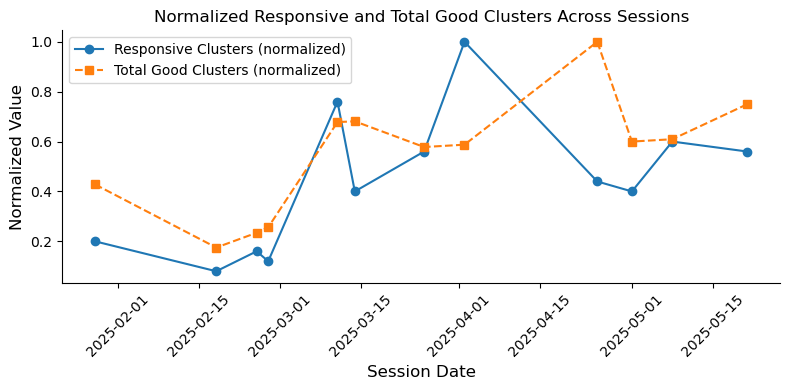

C:\Users\Ben\AppData\Local\Temp\ipykernel_21732\2632097677.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma', len(summary_results))


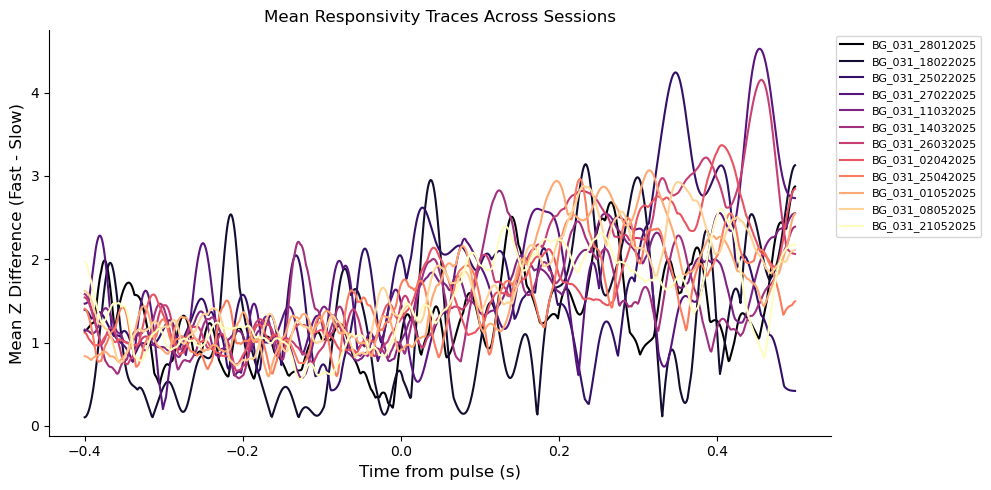

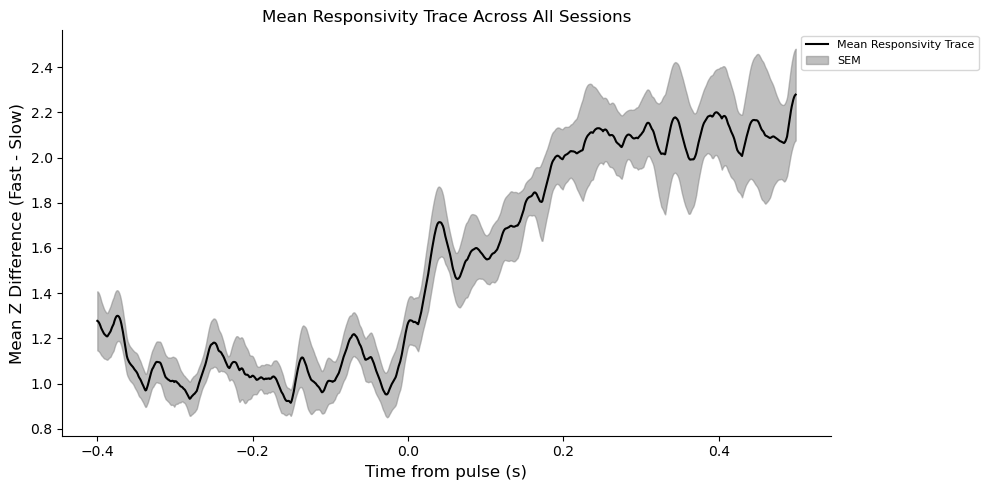

In [52]:
from matplotlib.cm import get_cmap

# Prepare data for plotting
session_dates = [s['date'] for s in summary_results]
session_ids = [s['session_id'] for s in summary_results]
n_clusters = [s['n_clusters'] for s in summary_results]

# Calculate total number of clusters per session (before filtering)
total_clusters = []
for sess in sessions:
    results = load_analysis_results_from_file(sess['pkl_path'])
    total_clusters.append(len(results['z_fast']))

# Calculate fraction of responsive clusters
fraction_responsive = [n / t if t > 0 else np.nan for n, t in zip(n_clusters, total_clusters)]

plt.figure(figsize=(8, 4))
plt.plot(session_dates, n_clusters, marker='o', label='Responsive Clusters')
plt.plot(session_dates, total_clusters, marker='s', linestyle='--', label='Total Good Clusters')
plt.xlabel('Session Date')
plt.ylabel('Number of Clusters')
plt.title('Responsive and Total Good Clusters Across Sessions')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Normalized plot: both series as a fraction of their own max
n_clusters_norm = np.array(n_clusters) / np.max(n_clusters) if np.max(n_clusters) > 0 else np.array(n_clusters)
total_clusters_norm = np.array(total_clusters) / np.max(total_clusters) if np.max(total_clusters) > 0 else np.array(total_clusters)

plt.figure(figsize=(8, 4))
plt.plot(session_dates, n_clusters_norm, marker='o', label='Responsive Clusters (normalized)')
plt.plot(session_dates, total_clusters_norm, marker='s', linestyle='--', label='Total Good Clusters (normalized)')
plt.xlabel('Session Date')
plt.ylabel('Normalized Value')
plt.title('Normalized Responsive and Total Good Clusters Across Sessions')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Plot mean responsivity traces for each session with a sequential color palette

cmap = get_cmap('magma', len(summary_results))
plt.figure(figsize=(10, 5))
for idx, s in enumerate(summary_results):
    if s['mean_diff'] is not None:
        plt.plot(s['t_vec'], s['mean_diff'], label=s['session_id'], color=cmap(idx))
plt.xlabel('Time from pulse (s)')
plt.ylabel('Mean Z Difference (Fast - Slow)')
plt.title('Mean Responsivity Traces Across Sessions')
plt.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

#plot the mean of the mean responsivity traces
mean_all = np.mean([s['mean_diff'] for s in summary_results if s['mean_diff'] is not None], axis=0)     
sem_all = np.std([s['mean_diff'] for s in summary_results if s['mean_diff'] is not None], axis=0) / np.sqrt(len(summary_results))
plt.figure(figsize=(10, 5)) 
plt.plot(s['t_vec'], mean_all, color='black', label='Mean Responsivity Trace')
plt.fill_between(s['t_vec'], mean_all - sem_all, mean_all + sem_all, color='gray', alpha=0.5, label='SEM')
plt.xlabel('Time from pulse (s)')   
plt.ylabel('Mean Z Difference (Fast - Slow)')
plt.title('Mean Responsivity Trace Across All Sessions')
plt.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

## 7. Save Aggregated Summary Results
Save the aggregated summary results for all sessions as a .pkl file for further analysis.

In [ ]:
aggregated_results = 

In [53]:
agg_path = os.path.join(results_dir, 'all_sessions_summary.pkl')
with open(agg_path, 'wb') as f:
    pickle.dump(summary_results, f)
print(f"Aggregated summary saved to {agg_path}")


Aggregated summary saved to ../pkls\all_sessions_summary.pkl


## 8. Next Steps
- Refine cluster selection/filtering parameters as needed.
- Explore additional cross-session analyses (e.g., compare responsivity by animal, condition, etc.).
- Use the saved summary .pkl files for further custom analyses or visualizations.


## 9. Plot Baseline Activity by Trial Outcome for Selected Clusters
This cell loads the aggregated summary, then for each session and each selected cluster, plots the baseline (pre-pulse) activity, comparing different trial outcomes within a session. You may need to adapt the code to match your trial outcome structure.

In [54]:
import seaborn as sns

# Load aggregated summary
agg_path = os.path.join(results_dir, 'all_sessions_summary.pkl')
with open(agg_path, 'rb') as f:
    all_summary = pickle.load(f)

# For each session, load the original results to access trial outcome and cluster data
for sess in sessions:
    print(f"Session: {sess['session_id']}")
    # Load per-session summary
    summary = next((s for s in all_summary if s['session_id'] == sess['session_id']), None)
    if summary is None:
        print(f"No summary for {sess['session_id']}")
        continue
    selected_clusters = summary['selected_clusters']
    # Load original results for trial outcome info
    results = load_analysis_results_from_file(sess['pkl_path'])
    z_fast = results['z_fast']
    t_vec = results['t_vec']
    # Example: Assume results['trial_outcomes'] is a dict: {cluster_id: [outcome per trial]}
    # and results['z_trials'] is a dict: {cluster_id: 2D array (n_trials x n_timepoints)}
    if 'trial_outcomes' not in results or 'z_trials' not in results:
        print(f"No trial outcome or z_trials info for {sess['session_id']}")
        continue
    for clu in selected_clusters:
        if clu not in results['z_trials'] or clu not in results['trial_outcomes']:
            continue
        z_trials = results['z_trials'][clu]  # shape: (n_trials, n_timepoints)
        outcomes = results['trial_outcomes'][clu]  # list/array of length n_trials
        # Define baseline window (e.g., t_vec < 0)
        baseline_mask = t_vec < 0
        baseline_vals = z_trials[:, baseline_mask].mean(axis=1)  # mean baseline per trial
        # Create DataFrame for plotting
        import pandas as pd
        df = pd.DataFrame({'Baseline': baseline_vals, 'Outcome': outcomes})
        plt.figure(figsize=(6, 4))
        sns.boxplot(x='Outcome', y='Baseline', data=df)
        sns.stripplot(x='Outcome', y='Baseline', data=df, color='k', alpha=0.5)
        plt.title(f'Session {sess["session_id"]} - Cluster {clu} Baseline by Outcome')
        plt.ylabel('Mean Baseline Z')
        plt.xlabel('Trial Outcome')
        plt.tight_layout()
        plt.show()

Session: BG_031_28012025
No trial outcome or z_trials info for BG_031_28012025
Session: BG_031_18022025
No trial outcome or z_trials info for BG_031_18022025
Session: BG_031_25022025
No trial outcome or z_trials info for BG_031_25022025
Session: BG_031_27022025
No trial outcome or z_trials info for BG_031_27022025
Session: BG_031_11032025
No trial outcome or z_trials info for BG_031_11032025
Session: BG_031_14032025
No trial outcome or z_trials info for BG_031_14032025
Session: BG_031_26032025
No trial outcome or z_trials info for BG_031_26032025
Session: BG_031_02042025
No trial outcome or z_trials info for BG_031_02042025
Session: BG_031_25042025
No trial outcome or z_trials info for BG_031_25042025
Session: BG_031_01052025
No trial outcome or z_trials info for BG_031_01052025
Session: BG_031_08052025
No trial outcome or z_trials info for BG_031_08052025
Session: BG_031_21052025
No trial outcome or z_trials info for BG_031_21052025
